In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from pandas.plotting import scatter_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [57]:
X = pd.read_csv("../data/food.csv")
X = X.drop(X.columns[[0,1,2]], axis=1)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Caloric Value         551 non-null    int64  
 1   Fat                   551 non-null    float64
 2   Saturated Fats        551 non-null    float64
 3   Monounsaturated Fats  551 non-null    float64
 4   Polyunsaturated Fats  551 non-null    float64
 5   Carbohydrates         551 non-null    float64
 6   Sugars                551 non-null    float64
 7   Protein               551 non-null    float64
 8   Dietary Fiber         551 non-null    float64
 9   Cholesterol           551 non-null    float64
 10  Sodium                551 non-null    float64
 11  Water                 551 non-null    float64
 12  Vitamin A             551 non-null    float64
 13  Vitamin B1            551 non-null    float64
 14  Vitamin B11           551 non-null    float64
 15  Vitamin B12           5

In [58]:
corr_matrix = X.corr()
corr_matrix

,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
Caloric Value,1.000000,0.909024,0.665258,0.704331,0.758928,0.625024,0.410723,0.598893,0.304923,0.536724,...,0.371276,0.161937,0.495743,0.451126,0.131766,0.549435,0.523691,0.135572,0.069112,0.542739
Fat,0.909024,1.000000,0.795589,0.791240,0.716734,0.471527,0.288702,0.406726,0.198173,0.475149,...,0.420332,0.129355,0.412762,0.315407,0.068340,0.437543,0.343493,0.066229,0.064206,0.553338
Saturated Fats,0.665258,0.795589,1.000000,0.663787,0.324472,0.331421,0.154351,0.179620,0.094875,0.314183,...,0.547000,0.118036,0.255907,0.140971,0.025680,0.294969,0.162685,0.024507,0.060047,0.611577
Monounsaturated Fats,0.704331,0.791240,0.663787,1.000000,0.500228,0.288309,0.138426,0.262478,0.121922,0.337116,...,0.234439,0.094831,0.322784,0.230745,0.076478,0.284255,0.224705,0.054017,0.023797,0.331404
Polyunsaturated Fats,0.758928,0.716734,0.324472,0.500228,1.000000,0.500277,0.394222,0.394690,0.279833,0.342577,...,0.109435,0.073461,0.383793,0.279707,0.069701,0.330167,0.305446,0.058985,0.039556,0.255773
Carbohydrates,0.625024,0.471527,0.331421,0.288309,0.500277,1.000000,0.614195,-0.066757,0.557989,-0.047062,...,0.094058,0.192708,0.407617,0.011123,0.125615,-0.041968,0.053409,0.109410,0.017069,0.235878
Sugars,0.410723,0.288702,0.154351,0.138426,0.394222,0.614195,1.000000,0.019160,0.293368,0.064312,...,0.065115,0.074332,0.193533,0.001524,0.033647,0.020926,0.029671,0.035608,0.008156,0.156439
Protein,0.598893,0.406726,0.179620,0.262478,0.394690,-0.066757,0.019160,1.000000,-0.055429,0.728761,...,0.265977,0.036108,0.270258,0.682505,0.108631,0.809509,0.788347,0.140550,0.071882,0.370117
Dietary Fiber,0.304923,0.198173,0.094875,0.121922,0.279833,0.557989,0.293368,-0.055429,1.000000,-0.170668,...,-0.008848,0.150227,0.309164,0.049186,0.170947,-0.080908,0.046130,0.149181,0.007368,0.079785
Cholesterol,0.536724,0.475149,0.314183,0.337116,0.342577,-0.047062,0.064312,0.728761,-0.170668,1.000000,...,0.283027,0.030135,0.254501,0.481903,0.048264,0.657747,0.560908,0.065227,0.092994,0.360772


In [59]:
y = X["Caloric Value"]
X = X.drop(columns = ["Caloric Value"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

array([[<Axes: title={'center': 'Fat'}>,
        <Axes: title={'center': 'Saturated Fats'}>,
        <Axes: title={'center': 'Monounsaturated Fats'}>,
        <Axes: title={'center': 'Polyunsaturated Fats'}>,
        <Axes: title={'center': 'Carbohydrates'}>,
        <Axes: title={'center': 'Sugars'}>],
       [<Axes: title={'center': 'Protein'}>,
        <Axes: title={'center': 'Dietary Fiber'}>,
        <Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'Sodium'}>,
        <Axes: title={'center': 'Water'}>,
        <Axes: title={'center': 'Vitamin A'}>],
       [<Axes: title={'center': 'Vitamin B1'}>,
        <Axes: title={'center': 'Vitamin B11'}>,
        <Axes: title={'center': 'Vitamin B12'}>,
        <Axes: title={'center': 'Vitamin B2'}>,
        <Axes: title={'center': 'Vitamin B3'}>,
        <Axes: title={'center': 'Vitamin B5'}>],
       [<Axes: title={'center': 'Vitamin B6'}>,
        <Axes: title={'center': 'Vitamin C'}>,
        <Axes: title={'center

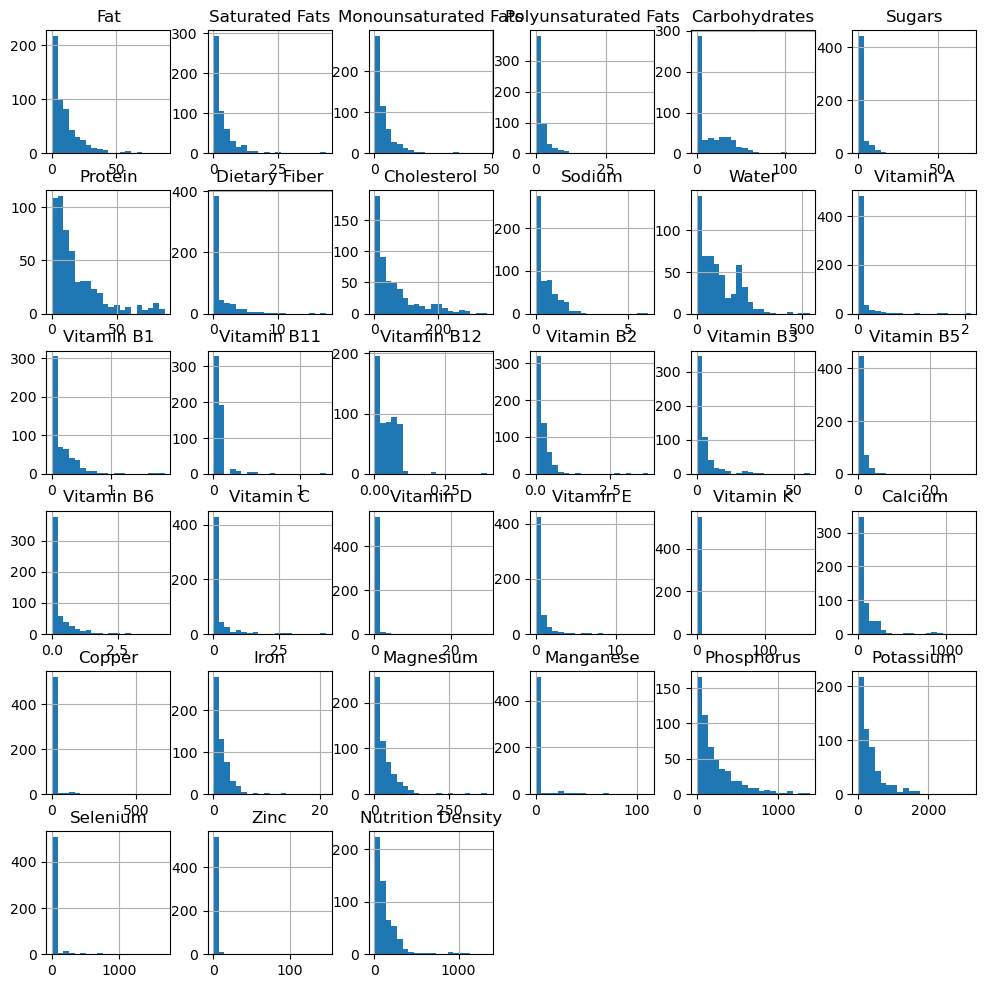

In [60]:
X.hist(bins=20, figsize=(12,12))

In [62]:
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy = "median")),
    ("standardize", StandardScaler())
])
pipeline = ColumnTransformer([("num", num_pipeline, X_train.columns)])
X_train_prepared = pipeline.fit_transform(X_train) # replace null values and standardize

X_test_prepared = pipeline.transform(X_test) # same, but not fit (should not fit from test)


In [63]:
model = LinearRegression()
model.fit(X_train_prepared, y_train)

y_pred = model.predict(X_test_prepared)

mse = mean_squared_error(y_test, y_pred)
r2 = model.score(X_test_prepared, y_test)

print(f"mse: {mse}")
print(f"r2: {r2}")

mse: 176.0214164109393
r2: 0.9967306077363357
